# JSON Data Exploration — `targets.nested.json`

**Objective**: Map **raw OpenSanctions records** to everything the retrieval pipeline consumes: **BM25**, **TF-IDF**, **identifier** lookup, **dense** encoding (notebook `07a`), and **RRF** fusion (ranked runs — not raw JSON).

**Dataset**: `data/raw_data/targets.nested.json` (3.7 GB, ~1.2M entities) · sample: `data/raw_data/sample_10k.json` (tracked 10K subset)

**What we trace here**

| Downstream | Raw / processed inputs |
|------------|-------------------------|
| **BM25** | `tokens` ← `text_blob` from flattened name, keyword, description, nested `sanctions`, `addressEntity` |
| **TF-IDF** | Same `text_blob` as string |
| **Identifiers** | Selected `properties.*` ID fields, stored raw |
| **Dense** | `caption`, `schema`, `metadata`-like fields (`country`, `programId`, `datasets`), identifiers, enriched text in notebook |
| **RRF** | Per-query ranked CSVs: `query_id`, `doc_id`, `rank` (`src/fusion/rrf.py`) |

**Classic questions** (still answered below): structure, schema mix, field coverage, nesting, quality.

**Phase 2 source of truth**: `src/preprocessing/document_builder.py`

## Setup

In [1]:
import json
import os
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns


def _find_project_root() -> Path:
    """Find repo root (folder containing data/raw_data/). Handles cwd=/ from Jupyter/Cursor."""
    marker = Path("data") / "raw_data"
    seeds = []
    seeds.append(Path.cwd().resolve())
    for key in (
        "IR_PROJECT_ROOT",
        "VSCODE_WORKSPACE_FOLDER",
        "CURSOR_WORKSPACE_FOLDER",
        "JUPYTER_SERVER_ROOT",
    ):
        v = os.environ.get(key)
        if v:
            seeds.append(Path(v).expanduser().resolve())
    seen = set()
    for seed in seeds:
        if seed in seen:
            continue
        seen.add(seed)
        for base in [seed, *seed.parents]:
            if (base / marker).is_dir():
                return base
    raise FileNotFoundError(
        f"Could not find {marker}. Set IR_PROJECT_ROOT to your IR_project path. cwd={Path.cwd()!r}"
    )


PROJECT_ROOT = _find_project_root()

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## IR pipeline mapping (raw record → consumers)

Phase 2 **`build_document`** flattens each JSON line into one **`documents.jsonl`** row with `doc_id`, `caption`, `schema`, `text_blob`, `tokens`, `identifiers`, `metadata`, `first_seen`, `last_seen`.

| Consumer | Uses |
|----------|------|
| **BM25** (`rank-bm25`) | `tokens` |
| **TF-IDF** (`sklearn`) | `text_blob` |
| **Identifier retriever** | `identifiers` (exact match) |
| **Dense retrieval** (`07a`) | Same record fields; notebook builds **enriched embedding text** (country/program/dataset labels + identifiers + fallback to `text_blob`) |
| **RRF** | **Does not read JSONL** — merges **ranked CSVs** from BM25 vs dense (etc.): columns `query_id`, `doc_id`, `rank` |

**`text_blob` order** (matches code): names → keyword fields → description fields → nested **sanctions** (authority/reason) → **addressEntity** (`full`). **`programId`** is **not** concatenated into `text_blob`; it lives under `metadata.programId` (merged from entity + nested sanctions).

## 1. Load Sample Data

First, let's examine the sample file to understand the structure.

In [2]:
# Load tracked sample file (10K records)
sample_path = PROJECT_ROOT / "data" / "raw_data" / "sample_10k.json"

sample_records = []
with open(sample_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            record = json.loads(line)
            sample_records.append(record)
        except json.JSONDecodeError as e:
            print(f"Error parsing line: {e}")

print(f"Loaded {len(sample_records)} sample records")

Loaded 10000 sample records


## 2. Examine First Record Structure

In [3]:
# Display first record
if sample_records:
    print("First record structure:")
    print(json.dumps(sample_records[2], indent=2))

First record structure:
{
  "id": "NK-224TRezPqwzhQZ37exWxtX",
  "caption": "SANAVBARI NIKITENKO",
  "schema": "Person",
  "referents": [
    "interpol-red-2019-108810"
  ],
  "datasets": [
    "interpol_red_notices"
  ],
  "origin": [
    "https://ws-public.interpol.int/notices/v1/red/2019-108810"
  ],
  "first_seen": "2024-03-04T17:09:51",
  "last_seen": "2026-03-21T09:47:46",
  "last_change": "2025-10-06T18:27:01",
  "properties": {
    "birthPlace": [
      "KOFARNIKHON TOWN"
    ],
    "country": [
      "tj"
    ],
    "programId": [
      "INTERPOL-RN"
    ],
    "nationality": [
      "ru"
    ],
    "birthDate": [
      "1992-06-28"
    ],
    "eyeColor": [
      "OTHD"
    ],
    "hairColor": [
      "OTHD"
    ],
    "topics": [
      "wanted",
      "crime"
    ],
    "gender": [
      "female"
    ],
    "lastName": [
      "NIKITENKO"
    ],
    "firstName": [
      "SANAVBARI"
    ],
    "name": [
      "SANAVBARI NIKITENKO"
    ],
    "sanctions": [
      {
        "id"

## 3. Top-level fields analysis

Field presence in the 100-record sample, plus **`target`** counts (boolean on the root object: primary entity row vs not — see OpenSanctions export). The code below prints counts and percentages for **`True`**, **`False`**, and **`None`** (missing `target` key or JSON `null`).

In [4]:
# Analyze top-level fields
top_level_fields = Counter()
for record in sample_records:
    for key in record.keys():
        top_level_fields[key] += 1

print("Top-level fields (from sample):")
for field, count in top_level_fields.most_common():
    pct = (count / len(sample_records)) * 100
    print(f"  {field:20s}: {count:>3} / {len(sample_records)} ({pct:>5.1f}%)")

# Root-level `target`: True = this line is the primary indexed entity; False is rare at root
target_counts = Counter(r.get("target") for r in sample_records)
n = len(sample_records)
_target_labels = {
    True: "True",
    False: "False",
    None: "None (missing `target` or null)",
}
print("\nTop-level `target` (same sample):")
for key in (True, False, None):
    if key in target_counts:
        c = target_counts[key]
        lbl = _target_labels[key]
        print(f"  target={lbl:36s}  {c:>3} / {n}  ({100 * c / n:5.1f}%)")
for key, c in sorted(target_counts.items(), key=lambda x: str(x[0])):
    if key not in (True, False, None):
        print(f"  target={key!r}  {c:>3} / {n}")

Top-level fields (from sample):
  id                  : 10000 / 10000 (100.0%)
  caption             : 10000 / 10000 (100.0%)
  schema              : 10000 / 10000 (100.0%)
  referents           : 10000 / 10000 (100.0%)
  datasets            : 10000 / 10000 (100.0%)
  first_seen          : 10000 / 10000 (100.0%)
  last_seen           : 10000 / 10000 (100.0%)
  last_change         : 10000 / 10000 (100.0%)
  properties          : 10000 / 10000 (100.0%)
  target              : 10000 / 10000 (100.0%)
  origin              : 3427 / 10000 ( 34.3%)

Top-level `target` (same sample):
  target=True                                  10000 / 10000  (100.0%)


## 4. Entity Type Distribution (Schema)

In [5]:
# Count entity types in sample
schema_counts = Counter()
for record in sample_records:
    schema = record.get('schema', 'Unknown')
    schema_counts[schema] += 1

print("Entity types in sample:")
for schema, count in schema_counts.most_common():
    pct = (count / len(sample_records)) * 100
    print(f"  {schema:20s}: {count:>3} ({pct:>5.1f}%)")

Entity types in sample:
  Person              : 5440 ( 54.4%)
  Company             : 2525 ( 25.2%)
  LegalEntity         : 799 (  8.0%)
  Vessel              : 621 (  6.2%)
  Organization        : 579 (  5.8%)
  Airplane            :  34 (  0.3%)
  Security            :   2 (  0.0%)


## 5. Properties Field Analysis

The `properties` field contains the main data for each entity.

In [6]:
# Analyze properties fields
property_fields = Counter()
property_types = defaultdict(set)

for record in sample_records:
    props = record.get('properties', {})
    for key, value in props.items():
        property_fields[key] += 1
        property_types[key].add(type(value).__name__)

print("Properties fields (from sample):")
print(f"{'Field':<30} {'Count':>5} {'Coverage':>8} {'Type'}")
print("-" * 70)
for field, count in property_fields.most_common(30):
    pct = (count / len(sample_records)) * 100
    types = ', '.join(property_types[field])
    print(f"{field:<30} {count:>5} {pct:>7.1f}%  {types}")

Properties fields (from sample):
Field                          Count Coverage Type
----------------------------------------------------------------------
topics                         10000   100.0%  list
name                            9999   100.0%  list
sanctions                       8971    89.7%  list
country                         7330    73.3%  list
address                         6947    69.5%  list
programId                       6755    67.5%  list
createdAt                       4672    46.7%  list
birthDate                       4636    46.4%  list
firstName                       4487    44.9%  list
lastName                        4486    44.9%  list
position                        3260    32.6%  list
alias                           3188    31.9%  list
middleName                      2591    25.9%  list
sector                          2575    25.8%  list
sourceUrl                       2476    24.8%  list
notes                           1842    18.4%  list
jurisdiction 

## 6. Text fields that feed BM25 and TF-IDF (`text_blob` / `tokens`)

Coverage in the sample for **every `properties` field** that Phase 2 concatenates into `text_blob` (see `document_builder.py`: `_NAME_FIELDS`, `_KEYWORD_FIELDS`, `_DESC_FIELDS`). Nested **sanctions** and **addressEntity** are summarized in §9–10.

In [7]:
# Same field groups as src/preprocessing/document_builder.py
NAME_FIELDS = [
    "name", "alias", "previousName", "weakAlias", "middleName",
    "fatherName", "motherName",
]
KEYWORD_FIELDS = [
    "position", "sector", "legalForm", "topics", "keywords", "birthPlace",
]
DESC_FIELDS = ["notes", "description", "summary"]


def _field_stats(field_name: str):
    count = 0
    total_length = 0
    for record in sample_records:
        props = record.get("properties", {})
        value = props.get(field_name)
        if not value:
            continue
        count += 1
        if isinstance(value, list):
            total_length += sum(len(str(v)) for v in value)
        else:
            total_length += len(str(value))
    pct = (count / len(sample_records)) * 100
    avg_len = total_length / count if count else 0
    return count, pct, avg_len


print("TEXT PATH → BM25 (`tokens`) + TF-IDF (`text_blob`)")
print("=" * 60)

for title, fields in [
    ("1. Name (normalize; no lemmatize on names)", NAME_FIELDS),
    ("2. Keyword (normalize)", KEYWORD_FIELDS),
    ("3. Free text (normalize + lemmatize in pipeline)", DESC_FIELDS),
]:
    print(f"\n{title}")
    print(f"{'Field':<22} {'Count':>5} {'Cov %':>8} {'Avg chars':>10}")
    print("-" * 52)
    for field in fields:
        c, p, a = _field_stats(field)
        print(f"{field:<22} {c:>5} {p:>7.1f}% {a:>10.1f}")

print("\nAlso folded into text_blob: nested sanctions (authority/reason) and addressEntity.full — see §9–10.")

TEXT PATH → BM25 (`tokens`) + TF-IDF (`text_blob`)

1. Name (normalize; no lemmatize on names)
Field                  Count    Cov %  Avg chars
----------------------------------------------------
name                    9999   100.0%       69.5
alias                   3174    31.7%       65.4
previousName             102     1.0%       33.7
weakAlias                279     2.8%       19.9
middleName              2591    25.9%        6.4
fatherName               756     7.6%       11.5
motherName               194     1.9%        7.1

2. Keyword (normalize)
Field                  Count    Cov %  Avg chars
----------------------------------------------------
position                3260    32.6%       57.2
sector                  2575    25.8%       20.9
legalForm               1367    13.7%       38.2
topics                 10000   100.0%       12.7
keywords                   7     0.1%       15.7
birthPlace               874     8.7%       31.7

3. Free text (normalize + lemmatize in 

## 7. Identifier fields (exact-match retrieval)

Same set as `_IDENTIFIER_FIELDS` in `document_builder.py` — stored **raw**, never tokenised.

In [8]:
IDENTIFIER_FIELDS = (
    "imoNumber",
    "mmsi",
    "callSign",
    "registrationNumber",
    "idNumber",
    "innCode",
    "ogrnCode",
    "kppCode",
    "npiCode",
    "uniqueEntityId",
    "taxNumber",
    "passportNumber",
    "leiCode",
    "vatCode",
    "email",
    "phone",
    "cryptoWalletAddress",
)

print("IDENTIFIER FIELDS → exact-match index (BM25/TF-IDF ignore these)")
print(f"{'Field':<24} {'Count':>5} {'Coverage':>8}")
print("-" * 44)

for field in IDENTIFIER_FIELDS:
    count = sum(
        1
        for record in sample_records
        if record.get("properties", {}).get(field)
    )
    pct = (count / len(sample_records)) * 100
    print(f"{field:<24} {count:>5} {pct:>7.1f}%")

IDENTIFIER FIELDS → exact-match index (BM25/TF-IDF ignore these)
Field                    Count Coverage
--------------------------------------------
imoNumber                  756     7.6%
mmsi                       148     1.5%
callSign                   149     1.5%
registrationNumber        1726    17.3%
idNumber                   962     9.6%
innCode                   1773    17.7%
ogrnCode                  1200    12.0%
kppCode                   1152    11.5%
npiCode                   1793    17.9%
uniqueEntityId            1738    17.4%
taxNumber                  744     7.4%
passportNumber             409     4.1%
leiCode                    188     1.9%
vatCode                     13     0.1%
email                      242     2.4%
phone                      306     3.1%
cryptoWalletAddress          0     0.0%


## 8. Metadata, timestamps, and nested `programId` (filtering, evaluation, dense)

Phase 2 stores **`metadata.country`**, **`metadata.programId`** (entity + merged from nested `sanctions`), **`metadata.datasets`**, plus **`first_seen`** / **`last_seen`**. These support **Type 6 qrels**, UI filters, and **Chroma metadata** in dense retrieval (`07a`). **RRF** still only fuses **ranked CSVs**, not these fields.

In [9]:
n = len(sample_records)


def pct(c):
    return 100.0 * c / n


print("METADATA COVERAGE (100-record sample)")
print("=" * 50)
print(
    f"{'Top-level datasets':<32} {sum(1 for r in sample_records if r.get('datasets')):>4}  ({pct(sum(1 for r in sample_records if r.get('datasets'))):5.1f}%)"
)
print(
    f"{'properties.country':<32} {sum(1 for r in sample_records if r.get('properties', {}).get('country')):>4}  ({pct(sum(1 for r in sample_records if r.get('properties', {}).get('country'))):5.1f}%)"
)
print(
    f"{'properties.programId':<32} {sum(1 for r in sample_records if r.get('properties', {}).get('programId')):>4}  ({pct(sum(1 for r in sample_records if r.get('properties', {}).get('programId'))):5.1f}%)"
)
print(
    f"{'first_seen / last_seen present':<32} {sum(1 for r in sample_records if r.get('first_seen') and r.get('last_seen')):>4}  ({pct(sum(1 for r in sample_records if r.get('first_seen') and r.get('last_seen'))):5.1f}%)"
)


def has_nested_program(r):
    for s in r.get("properties", {}).get("sanctions", []) or []:
        if not isinstance(s, dict):
            continue
        pid = s.get("properties", {}).get("programId")
        if pid:
            return True
    return False


nested_prog = sum(1 for r in sample_records if has_nested_program(r))
print(
    f"{'sanctions[].properties.programId':<32} {nested_prog:>4}  ({pct(nested_prog):5.1f}%)"
)

print("\n--- RRF ---")
print(
    "Reciprocal Rank Fusion reads two (or more) retrieval *run files* with columns: query_id, doc_id, rank."
)
print("See: src/fusion/rrf.py — no dependency on raw targets JSON at fusion time.")

METADATA COVERAGE (100-record sample)
Top-level datasets               10000  (100.0%)
properties.country               7330  ( 73.3%)
properties.programId             6755  ( 67.5%)
first_seen / last_seen present   10000  (100.0%)
sanctions[].properties.programId 6863  ( 68.6%)

--- RRF ---
Reciprocal Rank Fusion reads two (or more) retrieval *run files* with columns: query_id, doc_id, rank.
See: src/fusion/rrf.py — no dependency on raw targets JSON at fusion time.


## 9. Example records by entity type

In [10]:
# Show one example of each entity type
seen_schemas = set()

for record in sample_records:
    schema = record.get('schema', 'Unknown')
    
    if schema not in seen_schemas:
        seen_schemas.add(schema)
        print("=" * 80)
        print(f"EXAMPLE: {schema}")
        print("=" * 80)
        
        # Show key fields
        print(f"ID: {record.get('id')}")
        print(f"Caption: {record.get('caption')}")
        
        props = record.get('properties', {})
        ds = record.get("datasets", []) or []
        print(f"  datasets (top-level): {ds[:3]}{'...' if len(ds) > 3 else ''}")
        print(f"  programId: {props.get('programId', [])}")
        print("\nProperties (pipeline-relevant):")
        for key in [
            'name', 'alias', 'topics', 'country', 'programId',
            'description', 'notes', 'imoNumber', 'mmsi', 'registrationNumber',
        ]:
            if key in props:
                value = props[key]
                if isinstance(value, list):
                    print(f"  {key}: {value[:3]}...")
                else:
                    print(f"  {key}: {value}")
        print()

EXAMPLE: Company
ID: NK-223CQDBzp8MRkdJMDiqXn3
Caption: Myanmar Yatai International Holding Group Co., LTD.
  datasets (top-level): ['us_trade_csl', 'opencorporates', 'us_ofac_sdn']...
  programId: ['US-GLOMAG']

Properties (pipeline-relevant):
  name: ['Yatai New City', 'Myanmar Yatai International Holding Group Co., Ltd', 'SHWE KOKKO SPECIAL ECONOMIC ZONE']...
  alias: ['Yatai Smart Industrial New City', 'Yatai New City', 'Shwe Kokko Special Economic Zone']...
  topics: ['sanction', 'debarment']...
  country: ['mm']...
  programId: ['US-GLOMAG']...
  notes: ['(also SHWE KOKKO SPECIAL ECONOMIC ZONE, YATAI NEW CITY, YATAI SMART INDUSTRIAL NEW CITY)', '(also MYANMAR YATAI INTERNATIONAL HOLDING GROUP CO., LTD.)']...
  registrationNumber: ['103919088']...

EXAMPLE: Person
ID: NK-224TRezPqwzhQZ37exWxtX
Caption: SANAVBARI NIKITENKO
  datasets (top-level): ['interpol_red_notices']
  programId: ['INTERPOL-RN']

Properties (pipeline-relevant):
  name: ['SANAVBARI NIKITENKO']...
  topics: ['wan

## 10. Nested structure: address entities (and `sanctions` text for `text_blob`)

In [11]:
# Check for nested entities (like addressEntity)
nested_fields = ['addressEntity', 'linkedTo', 'ownershipAsset']

print("NESTED ENTITY FIELDS:")
for field in nested_fields:
    count = sum(1 for record in sample_records 
                if field in record.get('properties', {}))
    pct = (count / len(sample_records)) * 100
    print(f"  {field:<20}: {count:>3} / {len(sample_records)} ({pct:>5.1f}%)")

# Show example of nested address
for record in sample_records:
    props = record.get('properties', {})
    if 'addressEntity' in props:
        print("\nExample addressEntity:")
        print(json.dumps(props['addressEntity'][0], indent=2))
        break

NESTED ENTITY FIELDS:
  addressEntity       : 1740 / 10000 ( 17.4%)
  linkedTo            :   0 / 10000 (  0.0%)
  ownershipAsset      : 1705 / 10000 ( 17.1%)

Example addressEntity:
{
  "id": "addr-ee713d8aee0e4bcfe32761c9d76c0057f43b0f42",
  "caption": "Hpa-An City",
  "schema": "Address",
  "referents": [],
  "datasets": [
    "us_ofac_sdn"
  ],
  "first_seen": "2026-01-26T16:10:01",
  "last_seen": "2026-03-21T12:11:28",
  "last_change": "2026-01-26T16:10:01",
  "properties": {
    "city": [
      "Hpa-An City"
    ],
    "country": [
      "mm"
    ],
    "full": [
      "Hpa-An City"
    ]
  },
  "target": false
}


## 11. Analyze full dataset (streaming)

Stream `targets.nested.json` for scale stats (memory-safe). **Optional** — skip if the file is unavailable.

In [12]:
# Stream through full dataset and collect statistics
full_path = PROJECT_ROOT / "data" / "raw_data" / "targets.nested.json"

# Statistics collectors
total_count = 0
schema_dist = Counter()
field_coverage = Counter()
sample_size = 10000  # Sample first 10K for detailed analysis

print(f"Streaming through {full_path.name}...")
print("This may take a few minutes...\n")

with open(full_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        try:
            record = json.loads(line)
            total_count += 1
            
            # Schema distribution
            schema = record.get('schema', 'Unknown')
            schema_dist[schema] += 1
            
            # Field coverage (only for first 10K)
            if i < sample_size:
                props = record.get('properties', {})
                for key in props.keys():
                    field_coverage[key] += 1
            
            # Progress indicator
            if (i + 1) % 100000 == 0:
                print(f"  Processed {i+1:,} records...")
                
        except json.JSONDecodeError as e:
            print(f"Error at line {i}: {e}")
            continue

print(f"\nTotal records: {total_count:,}")

Streaming through targets.nested.json...
This may take a few minutes...



  Processed 100,000 records...


  Processed 200,000 records...


  Processed 300,000 records...


  Processed 400,000 records...


...

  Processed 900,000 records...


  Processed 1,000,000 records...


  Processed 1,100,000 records...


  Processed 1,200,000 records...



Total records: 1,245,931


## 12. Full dataset: entity type distribution


Entity Type Distribution (Full Dataset):
Entity Type                 Count Percentage
---------------------------------------------
Person                  1,004,596     80.63%
Company                   109,420      8.78%
LegalEntity                70,890      5.69%
Security                   20,373      1.64%
Organization               18,306      1.47%
CryptoWallet               13,674      1.10%
Vessel                      8,287      0.67%
Airplane                      342      0.03%
PublicBody                     23      0.00%
Address                        19      0.00%
Position                        1      0.00%


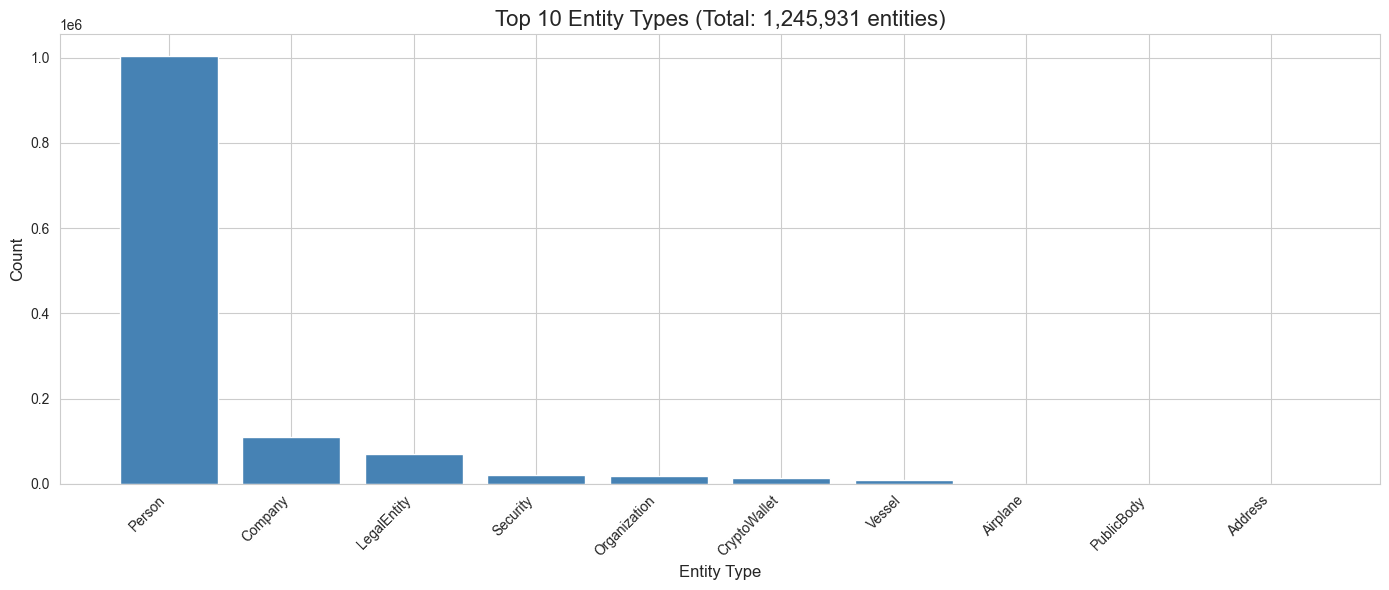

In [13]:
# Display full dataset schema distribution
print("\nEntity Type Distribution (Full Dataset):")
print(f"{'Entity Type':<20} {'Count':>12} {'Percentage':>10}")
print("-" * 45)

for schema, count in schema_dist.most_common():
    pct = (count / total_count) * 100
    print(f"{schema:<20} {count:>12,} {pct:>9.2f}%")

# Visualize
plt.figure(figsize=(14, 6))
schemas = [s for s, _ in schema_dist.most_common(10)]
counts = [c for _, c in schema_dist.most_common(10)]
plt.bar(schemas, counts, color='steelblue')
plt.title(f'Top 10 Entity Types (Total: {total_count:,} entities)', fontsize=16)
plt.xlabel('Entity Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 13. Field coverage (from 10K sample)

In [14]:
# Display field coverage
print(f"\nField Coverage (from first {sample_size:,} records):")
print(f"{'Field':<30} {'Count':>8} {'Coverage':>10}")
print("-" * 50)

for field, count in field_coverage.most_common(30):
    pct = (count / sample_size) * 100
    print(f"{field:<30} {count:>8,} {pct:>9.1f}%")


Field Coverage (from first 10,000 records):
Field                             Count   Coverage
--------------------------------------------------
topics                           10,000     100.0%
name                              9,999     100.0%
sanctions                         8,971      89.7%
country                           7,330      73.3%
address                           6,947      69.5%
programId                         6,755      67.5%
createdAt                         4,672      46.7%
birthDate                         4,636      46.4%
firstName                         4,487      44.9%
lastName                          4,486      44.9%
position                          3,260      32.6%
alias                             3,188      31.9%
middleName                        2,591      25.9%
sector                            2,575      25.8%
sourceUrl                         2,476      24.8%
notes                             1,842      18.4%
jurisdiction                      1,7

## 14. Key findings summary

Document observations after running all cells (especially §11–13 if you streamed the full file):

### Findings (template)

**Dataset size**
- Total entities: [from §11]
- File size: ~3.7 GB · format: JSONL

**Entity types**
- [Main schemas and share — §4 / §12]

**BM25 / TF-IDF (`text_blob`)**
- Name, keyword, and description field coverage — §6
- Nested `sanctions` + `addressEntity` — §10

**Identifiers**
- Coverage per `_IDENTIFIER_FIELDS` — §7

**Metadata / dense / evaluation**
- `country`, `programId`, `datasets`, timestamps — §8
- Dense enrichment text is built in `07a` (not only `text_blob`)

**RRF**
- Fusion consumes **ranked CSVs**, not raw JSON — §8 code cell

**Quality**
- [Missing values, inconsistent lists, etc.]

**Preprocessing implications**
1. Stream the large JSONL file (`src/preprocessing/parser.py`)
2. Flatten via `build_document` — order matters for `text_blob`
3. Keep `programId` in metadata for filtering, not as loose tokens in `text_blob`
4. Arrays: most fields are lists of strings
5. Identifiers: separate dict, never tokenised

## Next steps

1. **Preprocessing** — `python -m src.preprocessing.pipeline` → `data/json_format_data/.../documents.jsonl`
2. **Classical indices** — `scripts/build_index.py` (BM25, TF-IDF, identifier)
3. **Dense** — `notebooks/07a_dense_retrieval_creation_4_0_github.ipynb` (embeddings + Chroma; align corpus path with `data/json_format_data/...`)
4. **RRF** — export ranked runs as CSV, then `python -m src.fusion.rrf` (see module docstring)
5. **Learning module** — `learning/modules/01_text_processing_and_indexing/01_preprocessing.ipynb` walks tokenisation aligned with Phase 2